# Lab 04. ML-HW08. Части речи и именованные сущности в резюме

Датасет — `data/resumes_ru_6000_labeled.csv`: текст резюме и профессиональная область.

Дальше два шага.

Сначала ставим словам части речи и проверяем, каждому ли слову тег вообще проставлен. Без этого нельзя отличить должность «бухгалтер» от прилагательного «бухгалтерской».

Потом сами задаём типы сущностей, которые нужны в резюме, размечаем ими слова и учим две модели эти метки восстанавливать. Сравниваем модели не по доле всех верных слов, а по тому, находятся ли должности, программы и места работы.


## 1. Данные

В файле три колонки: номер, текст и класс. Классов шесть, по 1000 резюме: образование, финансы, медицина, строительство, торговля, транспорт.

Текст — список обязанностей и навыков. Имя человека и сюжет там почти не встречаются, зато встречаются должность, программа и работодатель. Схему сущностей ниже собираем из этого, а не из общего списка «персона, город, дата».

Для расчётов берём по 300 резюме из каждого класса, всего 1800 из 6000. Так все шесть областей одинаково попадают и в обучение, и в тест. `random_state=42` фиксирует выборку, чтобы цифры можно было повторить.


In [1]:
import re
import html
from collections import Counter
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

from razdel import tokenize, sentenize
from pymorphy3 import MorphAnalyzer
from nltk.tag import DefaultTagger, UnigramTagger, BigramTagger, TrigramTagger

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

candidates = [
    Path("data/resumes_ru_6000_labeled.csv"),
    Path("../data/resumes_ru_6000_labeled.csv"),
]
data_path = next(path for path in candidates if path.exists())
resumes = pd.read_csv(data_path)
print("файл:", data_path.as_posix())
print("всего резюме:", len(resumes))
print("колонки:", list(resumes.columns))
display(resumes["class"].value_counts().rename("резюме"))


файл: data/resumes_ru_6000_labeled.csv
всего резюме: 6000
колонки: ['index', 'text', 'class']


class
Образование и наука           1000
Финансы и бухгалтерия         1000
Медицина и здравоохранение    1000
Строительство и ремонт        1000
Торговля и продажи            1000
Транспорт и логистика         1000
Name: резюме, dtype: int64

In [2]:
PARTS = []
for _, group in resumes.groupby("class"):
    PARTS.append(group.sample(300, random_state=42))
sample = pd.concat(PARTS).sample(frac=1, random_state=42).reset_index(drop=True)

print("выборка:", len(sample))
display(sample["class"].value_counts().rename("в выборке"))
demo = sample.iloc[0]
print("\nкласс:", demo["class"])
print(demo["text"][:650].replace("\r", " "))


выборка: 1800


class
Финансы и бухгалтерия         300
Торговля и продажи            300
Строительство и ремонт        300
Медицина и здравоохранение    300
Транспорт и логистика         300
Образование и наука           300
Name: в выборке, dtype: int64


класс: Финансы и бухгалтерия
Легко и быстро справляюсь с большим объемом работы, качественно и внимательно выполняю порученную работу, легкообучаемая стремлюсь получать и использовать в работе новые знания. 
Хорошо взаимодействую с людьми, приветлива и доброжилательна. 
Уверенный пользователь ПК 
Ввод в базу данных с первичных документов. 
Составление сводной отчетности за месяц, квартал, год по выполнению плана продаж филиалом 
Обслуживание клиентов ( физ. 
лиц). 
Выполнение обязанностей старшего кассира. 
Открытие, закрытие операционного дня. 
Сверка банковских ценностей при открытии, закрытии хранилища ценностей. 
Прием и выдача банковских ценностей всем работникам см


**Вывод по данным.** Классы в выборке равны. Тексты короткие и деловые: инвентаризации, сметы, приём пациентов, 1С, Excel. Искать здесь имеет смысл должность, инструмент и место работы. Обычные слова обязанностей («ведение», «контроль», «документация») сущностями не являются, поэтому их будет большинство.


## 2. Части речи готовой библиотекой

Часть речи — подготовительный шаг. В должность и в место работы кладём только существительные. «Бухгалтерской» и «водительским» — прилагательные, их в сущность брать нельзя, иначе в должность попадёт половина документов.

Одно и то же написание бывает разными частями речи: «ответ» — существительное, «ответь» — глагол. `pymorphy3` возвращает несколько разборов. Мы берём первый: это самый частый вариант в словаре, соседние слова он не смотрит. На «стали» и «печь» ниже видно, что у слова есть и другой разбор, просто с меньшей вероятностью.

Окончания регулярными правилами не режем. Они не дают лемму и не отличают «бухгалтер» от «бухгалтерской». Готовый анализатор даёт и лемму, и часть речи. Стоит `pymorphy3`: на текущем Python это рабочая сборка того же словаря.


In [3]:
morph = MorphAnalyzer()

@lru_cache(maxsize=200_000)
def morph_info(word):
    parsed = morph.parse(word)[0]
    lemma = parsed.normal_form.replace("ё", "е")
    # str(): тег pymorphy3 — не обычная строка и ломает seaborn/numpy
    pos = parsed.tag.POS
    return lemma, (None if pos is None else str(pos))

print("Разные части речи у соседних по смыслу слов")
for word in ["ответ", "ответь", "бухгалтер", "бухгалтерской"]:
    parsed = morph.parse(word)[0]
    print(f"  {word:16} {parsed.normal_form:16} {parsed.tag}")

print("\nНесколько разборов у «стали» и «печь» — победитель не смотрит на контекст")
for word in ["стали", "печь"]:
    print(word)
    for parsed in morph.parse(word)[:3]:
        print(f"  {parsed.score:.3f}  {parsed.normal_form:10} {parsed.tag.POS}  {parsed.tag}")

print("\nЛатиница из резюме не получает русскую часть речи")
for word in ["Excel", "1С"]:
    parsed = morph.parse(word)[0]
    print(f"  {word:8} POS={parsed.tag.POS} tag={parsed.tag}")

Разные части речи у соседних по смыслу слов
  ответ            ответ            NOUN,inan,masc sing,accs
  ответь           ответить         VERB,perf,intr sing,impr,excl
  бухгалтер        бухгалтер        NOUN,anim,masc sing,nomn
  бухгалтерской    бухгалтерский    ADJF femn,sing,gent

Несколько разборов у «стали» и «печь» — победитель не смотрит на контекст
стали
  0.975  стать      VERB  VERB,perf,intr plur,past,indc
  0.011  сталь      NOUN  NOUN,inan,femn sing,gent
  0.005  сталь      NOUN  NOUN,inan,femn plur,nomn
печь
  0.571  печь       NOUN  NOUN,inan,femn sing,nomn
  0.286  печь       INFN  INFN,impf,tran
  0.143  печь       NOUN  NOUN,inan,femn sing,accs

Латиница из резюме не получает русскую часть речи
  Excel    POS=None tag=LATN
  1С       POS=None tag=UNKN


**Вывод.** «Бухгалтер» — существительное, «бухгалтерской» — прилагательное к «документации». В должность пойдёт только первое. «Стали» без фразы анализатор считает глаголом «стать», хотя это может быть и «сталь»: он выбирает частый словарный вариант, а не смысл предложения. `Excel` помечается как латиница и русской части речи не получает. Такие токены в эксперимент с частями речи не берём: ниже они пойдут как навыки, если есть в нашем списке программ.


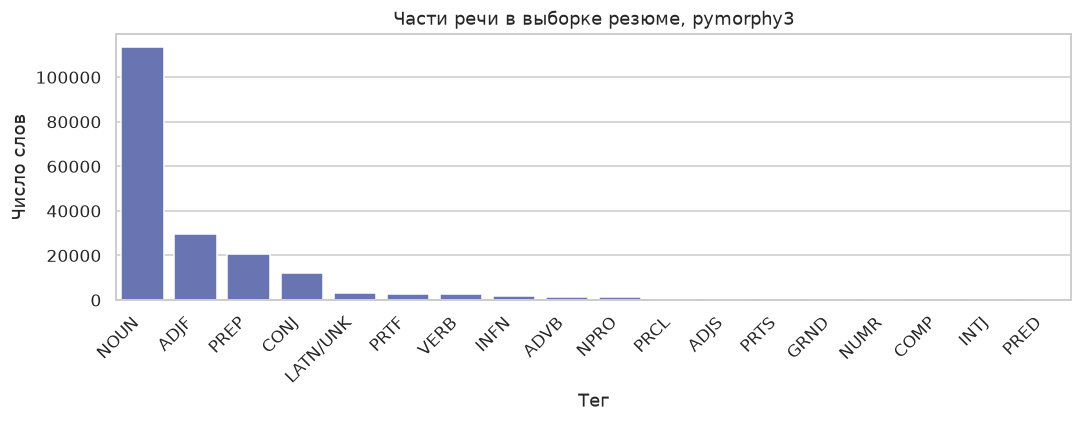

доля NOUN: 59.9%
всего слов с буквами: 189823


,слов
NOUN,113715
ADJF,29588
PREP,20566
CONJ,12190
LATN/UNK,2931
PRTF,2857
VERB,2593
INFN,1715
ADVB,1379
NPRO,1133


In [4]:
def word_tokens(text):
    words = []
    for sentence in sentenize(str(text).replace("\r", "\n")):
        for token in tokenize(sentence.text):
            word = token.text.strip()
            if re.search(r"[A-Za-zА-Яа-яЁё]", word):
                words.append(word)
    return words

pos_counter = Counter()
for text in sample["text"]:
    for word in word_tokens(text):
        _, pos = morph_info(word)
        pos_counter[pos or "LATN/UNK"] += 1

pos_counts = pd.Series(pos_counter).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=list(pos_counts.index), y=pos_counts.values, ax=ax, color="#5c6bc0")
ax.set_title("Части речи в выборке резюме, pymorphy3")
ax.set_xlabel("Тег")
ax.set_ylabel("Число слов")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

noun_share = pos_counts.get("NOUN", 0) / pos_counts.sum()
print(f"доля NOUN: {noun_share:.1%}")
print(f"всего слов с буквами: {int(pos_counts.sum())}")
display(pos_counts.rename("слов").to_frame())

**Вывод по распределению.** Существительных 59,9% — 113715 из 189823 слов. Обязанности записаны отглагольными именами («ведение», «составление», «контроль»), а не личными глаголами. Полных прилагательных 29588. Именно они отделяют «бухгалтерскую документацию» от должности «бухгалтер». Если всем словам поставить один тег `NOUN`, часть речи будет у каждого слова, но разбор от этого не появится: на тестовых словах с русской частью речи такой ответ верен только в 61,2% случаев.


## 3. Unigram, Bigram и Trigram

Эти теггеры учатся на предложениях, которые уже разметил `pymorphy3`, и на тесте пытаются повторить его тег.

- `UnigramTagger` помнит самый частый тег слова и на соседей не смотрит.
- `BigramTagger` смотрит ещё на тег предыдущего слова.
- `TrigramTagger` смотрит на два предыдущих тега.

Если такой пары или тройки в обучении не было, теггер без отката возвращает пусто: часть речи слову не ставится. Откат в этом случае передаёт слово более простому теггеру: trigram, потом bigram, потом unigram.

В конец цепочки не ставим правило «всем остальным — существительное». Иначе пустых ответов не останется, и проверка «размечено ли каждое слово» потеряет смысл: дырки закроет одна и та же константа.

Ручной разметки частей речи у резюме нет, поэтому точность считаем как совпадение с `pymorphy3`. Оговорка важная: этот эталон сам почти не зависит от соседних слов, и trigram не сможет обогнать unigram по accuracy. Зато хорошо видно покрытие — долю слов, которым тег вообще проставлен.

Предложения перемешиваем до разреза 80/20, чтобы тест не оказался одной профессией.


предложений: train 7416, test 1854
слов: train 150014, test 36092


,accuracy,coverage,accuracy среди размеченных,слов без тега,уникальных слов без тега
теггер,,,,,
DefaultTagger(NOUN),0.612,1.000,0.612,0,0
UnigramTagger,0.925,0.925,1.000,2700,2469
BigramTagger,0.335,0.335,1.000,24015,7382
TrigramTagger,0.246,0.246,1.000,27204,7741
Bigram + откат к Unigram,0.925,0.925,1.000,2700,2469
Trigram + откат к Bigram и Unigram,0.925,0.925,1.000,2700,2469


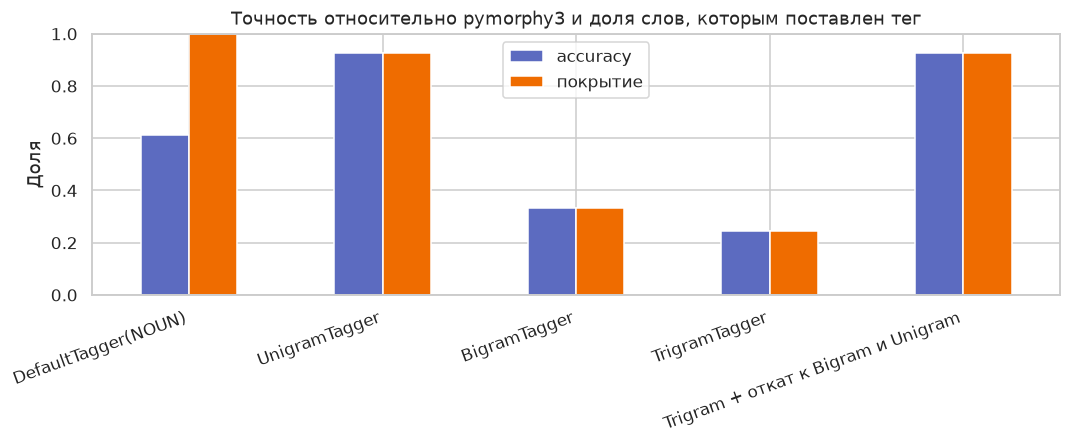

In [5]:
tagged_sents = []
for text in sample["text"]:
    for sentence in sentenize(str(text).replace("\r", "\n")):
        pairs = []
        for token in tokenize(sentence.text):
            word = token.text.strip()
            if not re.search(r"[A-Za-zА-Яа-яЁё]", word):
                continue
            _, pos = morph_info(word)
            if pos is None:
                continue
            pairs.append((word, pos))
        if len(pairs) >= 3:
            tagged_sents.append(pairs)

order = np.random.default_rng(42).permutation(len(tagged_sents))
tagged_sents = [tagged_sents[i] for i in order]
cut = int(len(tagged_sents) * 0.8)
train_sents = tagged_sents[:cut]
test_sents = tagged_sents[cut:]
print(f"предложений: train {len(train_sents)}, test {len(test_sents)}")
print(f"слов: train {sum(len(s) for s in train_sents)}, test {sum(len(s) for s in test_sents)}")

default_tagger = DefaultTagger("NOUN")
unigram = UnigramTagger(train_sents)
bigram = BigramTagger(train_sents)
trigram = TrigramTagger(train_sents)
bigram_bo = BigramTagger(train_sents, backoff=unigram)
trigram_bo = TrigramTagger(train_sents, backoff=bigram_bo)

def tagger_report(name, tagger):
    total = correct = covered = 0
    missed = []
    for sent in test_sents:
        words = [word for word, _ in sent]
        predicted = tagger.tag(words)
        for (word, gold), (_, pred) in zip(sent, predicted):
            total += 1
            if pred is None:
                missed.append(word)
                continue
            covered += 1
            if pred == gold:
                correct += 1
    return {
        "теггер": name,
        "accuracy": correct / total,
        "coverage": covered / total,
        "accuracy среди размеченных": (correct / covered) if covered else 0.0,
        "слов без тега": total - covered,
        "уникальных слов без тега": len({w.lower() for w in missed}),
    }

rows = [
    tagger_report("DefaultTagger(NOUN)", default_tagger),
    tagger_report("UnigramTagger", unigram),
    tagger_report("BigramTagger", bigram),
    tagger_report("TrigramTagger", trigram),
    tagger_report("Bigram + откат к Unigram", bigram_bo),
    tagger_report("Trigram + откат к Bigram и Unigram", trigram_bo),
]
metrics_pos = pd.DataFrame(rows).set_index("теггер")
display(metrics_pos.round(3))

plot_df = metrics_pos.loc[
    [
        "DefaultTagger(NOUN)",
        "UnigramTagger",
        "BigramTagger",
        "TrigramTagger",
        "Trigram + откат к Bigram и Unigram",
    ],
    ["accuracy", "coverage"],
]
fig, ax = plt.subplots(figsize=(10, 4.2))
plot_df.plot(kind="bar", ax=ax, color=["#5c6bc0", "#ef6c00"])
ax.set_ylim(0, 1)
ax.set_ylabel("Доля")
ax.set_xlabel("")
ax.set_title("Точность относительно pymorphy3 и доля слов, которым поставлен тег")
ax.legend(["accuracy", "покрытие"])
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Вывод по теггерам.** `DefaultTagger` ставит тег каждому слову, покрытие равно 1, accuracy равна 0,612. Это доля существительных среди тестовых слов, а не качество разметки.

`UnigramTagger`: accuracy и покрытие совпали — 0,925. Среди слов, которым тег всё-таки поставлен, совпадение с `pymorphy3` равно 1,000. Ошибки здесь не путаница частей речи, а пропуски: 2700 токенов, 2469 уникальных слов.

`BigramTagger` без отката покрывает только 0,335, `TrigramTagger` без отката — 0,246 (без тега 27204 токена). Тройка «два предыдущих тега + текущее слово» в тесте почти не повторяет обучение, даже если само слово знакомо.

Откат возвращает и accuracy, и покрытие к 0,925. Trigram и bigram редко оставляют решение себе и отдают слово unigram. Обогнать unigram по accuracy эта цепочка не может: эталон `pymorphy3` сам не смотрит на соседние слова.

Неразмеченные слова у `TrigramTagger` с откатом остаются. Они выделены в следующей ячейке.


In [6]:
def render_tags(pairs, empty_note="нет тега"):
    chunks = []
    for word, tag in pairs:
        safe = html.escape(word)
        if tag is None:
            chunks.append(
                f'<mark style="background:#ffe082;padding:1px 3px;border-radius:3px">{safe}</mark>'
                f'<sub style="color:#e65100">{empty_note}</sub>'
            )
        else:
            chunks.append(f'{safe}<sub style="color:#1565c0">{html.escape(str(tag))}</sub>')
    display(HTML("<p>" + " ".join(chunks) + "</p>"))

# Одно и то же тестовое предложение тремя теггерами.
example = next(sent for sent in test_sents if 8 <= len(sent) <= 14)
example_words = [word for word, _ in example]
print("Одно предложение. Жёлтым отмечено слово без части речи.")
for name, tagger in [
    ("UnigramTagger", unigram),
    ("BigramTagger без отката", bigram),
    ("TrigramTagger без отката", trigram),
    ("TrigramTagger с откатом", trigram_bo),
]:
    print(name)
    render_tags(tagger.tag(example_words))

print("Слова, которым TrigramTagger с откатом так и не поставил часть речи")
miss_counter = Counter()
miss_rows = []
seen_pairs = set()
for sent in test_sents:
    words = [word for word, _ in sent]
    gold = {word_i: tag for word_i, (_, tag) in enumerate(sent)}
    uni_pred = dict(unigram.tag(words))
    for word, pred in trigram_bo.tag(words):
        if pred is not None:
            continue
        key = word.lower()
        miss_counter[key] += 1
        if key not in seen_pairs:
            seen_pairs.add(key)
            miss_rows.append(
                {
                    "слово": word,
                    "тег Unigram": uni_pred.get(word),
                    "тег pymorphy3": morph_info(word)[1],
                }
            )

miss_table = pd.DataFrame(miss_rows)
miss_table["сколько раз без тега"] = miss_table["слово"].str.lower().map(miss_counter)
miss_table = miss_table.sort_values("сколько раз без тега", ascending=False)
print(
    f"токенов без тега: {sum(miss_counter.values())}; "
    f"уникальных слов: {len(miss_counter)}"
)
display(miss_table.head(40).reset_index(drop=True))

print("Те же слова в контексте предложения (каждое неразмеченное подсвечено)")
shown = 0
for sent in test_sents:
    words = [word for word, _ in sent]
    predicted = trigram_bo.tag(words)
    if any(tag is None for _, tag in predicted) and 6 <= len(predicted) <= 18:
        render_tags(predicted)
        shown += 1
    if shown >= 6:
        break

print("Для сравнения: TrigramTagger без отката гасит и знакомые слова, если не видел контекст")
shown = 0
for sent in test_sents:
    words = [word for word, _ in sent]
    predicted = trigram.tag(words)
    n_empty = sum(tag is None for _, tag in predicted)
    if 0 < n_empty < len(predicted) and len(predicted) <= 16:
        render_tags(predicted)
        shown += 1
    if shown >= 3:
        break

Одно предложение. Жёлтым отмечено слово без части речи.
UnigramTagger


BigramTagger без отката


TrigramTagger без отката


TrigramTagger с откатом


Слова, которым TrigramTagger с откатом так и не поставил часть речи
токенов без тега: 2700; уникальных слов: 2469


,слово,тег Unigram,тег pymorphy3,сколько раз без тега
0,лицо,None,NOUN,5
1,мореплавания,None,NOUN,5
2,нагрузок,None,NOUN,4
3,швартовка,None,NOUN,4
4,Документационное,None,ADJF,3
5,рациональному,None,ADJF,3
6,Задачи,None,NOUN,3
7,реактивами,None,NOUN,3
8,электроэнергией,None,NOUN,3
9,закономерностей,None,NOUN,3


Те же слова в контексте предложения (каждое неразмеченное подсвечено)


Для сравнения: TrigramTagger без отката гасит и знакомые слова, если не видел контекст


**Вывод по пропущенным словам.** Жёлтым отмечены слова, которым `TrigramTagger` не поставил часть речи.

У теггера с откатом пустыми остаются 2700 токенов и 2469 уникальных слов. Их не было в обучающих предложениях: unigram тоже возвращает `None`, и цепочке больше некуда отступать. Это не редкая часть речи, а неизвестное слово. `pymorphy3` часть речи у них знает — «лицо», «мореплавания», «швартовка» в таблице размечены словарём, — потому что это морфоанализатор, а не n-грамма по выборке. В таблице самые частые пропуски, в шести предложениях подсвечен каждый.

У `TrigramTagger` без отката жёлтым загораются и обычные, уже знакомые слова: теггер не видел эту тройку тегов и оставляет пусто. На всех словах части речи так не выделяются. Для резюме рабочий вариант — готовый `pymorphy3`. Unigram нужен как проверка покрытия, trigram без отката как разметчик не годится.


## 4. Своя схема сущностей для резюме

Сущность здесь — одно слово с типом, который мы задали сами. Соседние слова модель пока не склеивает: у «менеджер по продажам» метку получит «менеджер», а не вся группа.

Типы собраны по текстам выборки, по тому, чем резюме бухгалтера отличается от резюме врача:

| Тип | Что это в резюме | Примеры |
| --- | --- | --- |
| POSITION | должность | бухгалтер, врач, водитель, прораб |
| ORG | работодатель или тип места | школа, банк, больница, компания |
| SKILL | программа или инструмент | 1С, Excel, AutoCAD, ЗУП, СБИС |
| EDU | образование и документ | диплом, бакалавр, курсы, переподготовка |
| PERIOD | календарный год или стаж | 2015, 27.05.2015, стаж |
| LOC | город | Казань, Москва |
| O | не сущность | ведение, контроль, документация |

Список узкий, и это решение, а не недосмотр.

- «Организация работы» — процесс, не работодатель. Слово «организация» в места работы не кладём.
- «Бухгалтерской» и «водительским» — прилагательные. В должность попадает только существительное.
- «Курс лечения» и «курс валюты» — не образование. Как образование берём формы «курсы / курсов / курсам», голое «курс» не берём.


In [7]:
POSITION = {
    "бухгалтер", "менеджер", "водитель", "врач", "инженер", "логист", "директор",
    "прораб", "кассир", "медсестра", "аналитик", "учитель", "преподаватель",
    "воспитатель", "продавец", "кладовщик", "экономист", "фельдшер", "фармацевт",
    "лаборант", "методист", "тренер", "инструктор", "курьер", "экспедитор",
    "администратор", "оператор", "секретарь", "аудитор", "финансист", "консультант",
    "агент", "мерчендайзер", "супервайзер", "координатор", "специалист",
    "руководитель", "начальник", "заведующий", "мастер", "слесарь", "электрик",
    "маляр", "сварщик", "механик", "технолог", "диспетчер", "грузчик", "охранник",
    "юрист", "маркетолог", "риелтор", "повар", "парикмахер", "косметолог",
    "стоматолог", "хирург", "терапевт", "педиатр", "кардиолог", "невролог",
    "гинеколог", "уролог", "анестезиолог", "реаниматолог", "ординатор", "санитар",
    "сиделка", "няня", "логопед", "психолог", "дефектолог", "библиотекарь",
    "доцент", "профессор", "педагог", "репетитор", "вожатый", "провизор",
    "товаровед", "архитектор", "сметчик", "геодезист", "энергетик", "сантехник",
    "монтажник", "машинист", "пилот", "комплектовщик", "закупщик",
}
ORG = {
    "компания", "предприятие", "магазин", "школа", "больница", "поликлиника",
    "клиника", "аптека", "банк", "завод", "университет", "институт", "колледж",
    "техникум", "академия", "автошкола", "санаторий", "фирма", "холдинг", "кафе",
    "ресторан", "гостиница", "салон", "депо", "терминал", "аэропорт", "вокзал",
}
EDU = {
    "образование", "диплом", "бакалавр", "магистр", "аспирант", "аспирантура",
    "бакалавриат", "магистратура", "ординатура", "интернатура", "аттестат",
    "переподготовка",
}
LOC = {
    "казань", "москва", "петербург", "санкт-петербург", "новосибирск",
    "екатеринбург", "уфа", "самара", "омск", "челябинск", "краснодар", "пермь",
    "воронеж", "волгоград", "красноярск", "тюмень", "ижевск", "барнаул", "иркутск",
    "хабаровск", "ярославль", "владивосток", "томск", "оренбург", "кемерово",
    "рязань", "астрахань", "пенза", "липецк", "тула", "киров", "чебоксары",
    "калининград", "брянск", "иваново", "белгород", "сочи", "тверь", "ставрополь",
    "курск", "ульяновск", "махачкала", "архангельск", "владимир", "калуга",
    "смоленск", "саранск", "череповец", "вологда", "орёл", "орел", "сургут",
}
SKILL = {
    "1с", "1c", "excel", "exel", "word", "msword", "office", "autocad", "crm",
    "sap", "outlook", "powerpoint", "photoshop", "internet", "интернет", "windows",
    "erp", "gps", "archicad", "coreldraw", "kpi", "b2b", "wms", "lotus", "компас",
    "сбис", "зуп", "битрикс", "bitrix", "iso", "access", "visio", "sketchup",
    "revit", "linux", "sql", "python", "java", "пдд",
}
COURSE_FORMS = {"курсы", "курсов", "курсам", "курсами"}
LABELS = ["POSITION", "ORG", "SKILL", "EDU", "PERIOD", "LOC", "O"]
COLORS = {
    "POSITION": "#bbdefb",
    "ORG": "#c8e6c9",
    "SKILL": "#ffe0b2",
    "EDU": "#e1bee7",
    "PERIOD": "#fff59d",
    "LOC": "#b2dfdb",
}

def norm(word):
    return word.lower().replace("ё", "е").strip(".,;:|•()[]\"\"'«»")

def prepare_tokens(text):
    raw = [token.text.strip() for token in tokenize(str(text).replace("\r", " "))]
    words = []
    index = 0
    while index < len(raw):
        token = raw[index]
        if not token:
            index += 1
            continue
        # razdel режет «1С» на «1» и «С»: для резюме это одна программа
        if token == "1" and index + 1 < len(raw) and raw[index + 1][:1].lower() in "сc":
            words.append("1С")
            index += 2
            continue
        parts = [part for part in re.split(r"[-–—]", token) if part]
        words.extend(parts or [token])
        index += 1
    return [word for word in words if re.search(r"[0-9A-Za-zА-Яа-яЁё]", word)]

def entity_of(word):
    raw = norm(word)
    if not raw:
        return "O"
    if raw in SKILL or raw.startswith("1с") or raw.startswith("1c"):
        return "SKILL"
    if re.search(r"(?:19|20)\d{2}", raw):
        return "PERIOD"
    if raw in COURSE_FORMS:
        return "EDU"
    lemma, pos = morph_info(word)
    if lemma == "стаж":
        return "PERIOD"
    if lemma in EDU:
        return "EDU"
    if pos == "NOUN" and lemma in POSITION:
        return "POSITION"
    if pos == "NOUN" and lemma in ORG:
        return "ORG"
    if pos == "NOUN" and lemma in LOC:
        return "LOC"
    return "O"

print(
    "размер ручных словарей:",
    {
        "POSITION": len(POSITION),
        "ORG": len(ORG),
        "SKILL": len(SKILL),
        "EDU": len(EDU),
        "LOC": len(LOC),
    },
)

# Контрольные фразы размечены вручную. Словарь должен попасть в них и не разметить ловушки.
GOLD = [
    ("Менеджер по продажам: поиск и привлечение клиентов", {"менеджер": "POSITION"}),
    (
        "Умение работать в программах: 1С, ЗУП, СБИС, Word, Excel",
        {"1с": "SKILL", "зуп": "SKILL", "сбис": "SKILL", "word": "SKILL", "excel": "SKILL"},
    ),
    (
        "Администрирование локальной сети и доступа к Интернет в школе.",
        {"интернет": "SKILL", "школе": "ORG"},
    ),
    ("Практикующий врач терапевт", {"врач": "POSITION", "терапевт": "POSITION"}),
    ("Работа с водительским составом", {}),
    ("Ведение бухгалтерской и хозяйственной документации", {}),
    ("организация работы цеха", {}),
    ("опыт работы в банке и в компании", {"банке": "ORG", "компании": "ORG"}),
    ("увольнение было 27.05.2015г. в Казани", {"27.05.2015": "PERIOD", "казани": "LOC"}),
    ("отделение-врач-хирург", {"отделение": "O", "врач": "POSITION", "хирург": "POSITION"}),
    (
        "Есть диплом о высшем образовании и курсы переподготовки",
        {"диплом": "EDU", "образовании": "EDU", "курсы": "EDU", "переподготовки": "EDU"},
    ),
]
problems = []
for text, expected in GOLD:
    words = prepare_tokens(text)
    tags = [entity_of(word) for word in words]
    print(" | ".join(f"{word}/{tag}" for word, tag in zip(words, tags)))
    for word, tag in zip(words, tags):
        wanted = expected.get(norm(word), "O")
        if tag != wanted:
            problems.append((text, word, tag, wanted))
print("расхождений с ручной проверкой:", len(problems))
if problems:
    display(pd.DataFrame(problems, columns=["фраза", "слово", "получили", "ожидали"]))

размер ручных словарей: {'POSITION': 90, 'ORG': 27, 'SKILL': 39, 'EDU': 12, 'LOC': 52}
Менеджер/POSITION | по/O | продажам/O | поиск/O | и/O | привлечение/O | клиентов/O
Умение/O | работать/O | в/O | программах/O | 1С/SKILL | ЗУП/SKILL | СБИС/SKILL | Word/SKILL | Excel/SKILL
Администрирование/O | локальной/O | сети/O | и/O | доступа/O | к/O | Интернет/SKILL | в/O | школе/ORG
Практикующий/O | врач/POSITION | терапевт/POSITION
Работа/O | с/O | водительским/O | составом/O
Ведение/O | бухгалтерской/O | и/O | хозяйственной/O | документации/O
организация/O | работы/O | цеха/O
опыт/O | работы/O | в/O | банке/ORG | и/O | в/O | компании/ORG
увольнение/O | было/O | 27.05.2015/PERIOD | г/O | в/O | Казани/LOC
отделение/O | врач/POSITION | хирург/POSITION
Есть/O | диплом/EDU | о/O | высшем/O | образовании/EDU | и/O | курсы/EDU | переподготовки/EDU
расхождений с ручной проверкой: 0


**Вывод по словарю.** Контрольные фразы сошлись с тем, как мы сами их разметили. «1С» снова одно слово и это навык. «Врач-хирург» распадается на две должности. «Бухгалтерской» и «водительским» остаются обычными словами. «Организация работы» не становится работодателем. Год внутри `27.05.2015` получает PERIOD, «Казани» — город.

Это не отдельная ручная разметка каждого резюме, а применение нашего списка. Модель ниже учится повторять эти метки по форме слова, в том числе у форм, которых не было в обучении. Если слова нет в списке, и модель, и проверка считают его фоном.


токенов: train 144419, test 49997
резюме: train 1350 test 450


,токенов
tag,
POSITION,1540
ORG,1629
SKILL,838
EDU,126
PERIOD,79
LOC,4
O,190200


доля O: 97.8%


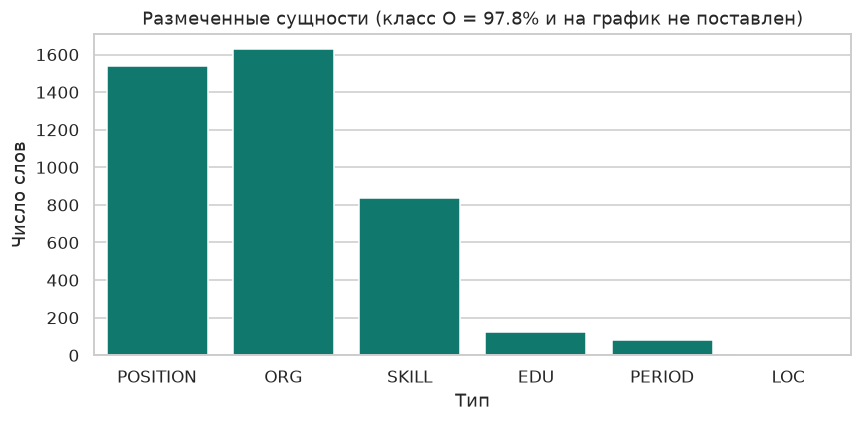

Примеры разметки на резюме из выборки


In [8]:
train_docs, test_docs = train_test_split(
    sample, test_size=0.25, random_state=42, stratify=sample["class"]
)
train_ids = set(train_docs["index"])

records = []
for _, row in sample.iterrows():
    split = "train" if row["index"] in train_ids else "test"
    for sent_id, sentence in enumerate(sentenize(str(row["text"]).replace("\r", "\n"))):
        words = prepare_tokens(sentence.text)
        if not words:
            continue
        for word in words:
            records.append(
                {
                    "doc": row["index"],
                    "split": split,
                    "sent": sent_id,
                    "word": word,
                    "key": norm(word),
                    "tag": entity_of(word),
                    "class": row["class"],
                }
            )

tokens = pd.DataFrame.from_records(records)
train_df = tokens[tokens["split"] == "train"]
test_df = tokens[tokens["split"] == "test"]
print(f"токенов: train {len(train_df)}, test {len(test_df)}")
print("резюме: train", train_docs.shape[0], "test", test_docs.shape[0])

tag_counts = tokens["tag"].value_counts().reindex(LABELS).fillna(0).astype(int)
display(tag_counts.rename("токенов").to_frame())
o_share = tag_counts["O"] / tag_counts.sum()
print(f"доля O: {o_share:.1%}")

entity_counts = tag_counts.drop("O")
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=list(entity_counts.index), y=entity_counts.values, ax=ax, color="#00897b")
ax.set_title(f"Размеченные сущности (класс O = {o_share:.1%} и на график не поставлен)")
ax.set_xlabel("Тип")
ax.set_ylabel("Число слов")
plt.tight_layout()
plt.show()

def render_ner(words, tags):
    chunks = []
    for word, tag in zip(words, tags):
        safe = html.escape(word)
        if tag == "O":
            chunks.append(safe)
        else:
            chunks.append(
                f'<span style="background:{COLORS[tag]};padding:1px 4px;border-radius:3px">'
                f'{safe}<sub>{tag}</sub></span>'
            )
    display(HTML("<p>" + " ".join(chunks) + "</p>"))

print("Примеры разметки на резюме из выборки")
shown = 0
for text in sample["text"].sample(120, random_state=1):
    for sentence in sentenize(str(text).replace("\r", "\n")):
        words = prepare_tokens(sentence.text)
        tags = [entity_of(word) for word in words]
        kinds = {tag for tag in tags if tag != "O"}
        if len(kinds) >= 2 and 5 <= len(words) <= 24:
            render_ner(words, tags)
            shown += 1
        if shown >= 5:
            break
    if shown >= 5:
        break

**Вывод по разметке.** Класс O — это 190200 токенов из 194416, то есть 97,8%. Обычные слова обязанностей сущностями не являются. Среди сущностей чаще всего места работы (1629) и должности (1540), затем программы (838). Образование (126) и годы (79) редки, города нашлись всего 4 раза: в этих резюме мало анкетных шапок с адресом. Все четыре города попали в обучающую часть, в тесте городов нет.

Из-за такого перекоса accuracy дальше нельзя брать главной метрикой. Модель, которая всему ставит O, уже «точна» на 97,8% и при этом не находит ни одной должности.


## 5. Сеть на отдельных словах

Каждый пример — одно слово, ответ — один из семи типов. Соседние слова сеть не видит. Так устроена и наша разметка: метка сидит на слове, а не на куске фразы.

Что делает сеть:

1. слово переводится в номера кусков словаря, последовательность добивается до длины 10;
2. каждый номер получает вектор длины 64;
3. из этих векторов берётся максимум по каждой координате — остаётся один вектор слова;
4. два полносвязных слоя, 300 и 50 нейронов;
5. вектор после пулинга склеивается со вторым слоем;
6. softmax на 7 классов: должность, место, программа, образование, год, город, фон.

Кодировщик классов учится один раз на полном списке меток. Иначе номера классов на обучении и на проверке разъедутся.

Учим до 3 эпох, оптимизатор Adam, ошибка — категориальная по номеру класса. Батч 64. В истории смотрим accuracy и ошибку. Внутри обучения 20% слов из train отложены как валидация, итоговые цифры считаем на резюме, которые в обучение не входили.

Эпоху выбираем по ошибке на валидации, а не по последнему шагу. Если ошибка на валидации растёт, а на обучении падает, сеть уже запоминает конкретные строки и хуже ставит метку новым словам. Веса возвращаем к лучшей эпохе.

Accuracy при 97,8% фона почти ничего не говорит: модель «всем словам — не сущность» уже почти так же точна. Рядом считаем macro-F1 по шести типам сущностей. Там фон не входит, и видно, находятся ли должности и программы.


классы сети: [np.str_('EDU'), np.str_('LOC'), np.str_('O'), np.str_('ORG'), np.str_('PERIOD'), np.str_('POSITION'), np.str_('SKILL')]


слов в словаре сети: 17895


Epoch 1/3


C:\Users\37727\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1806/1806 - 13s - 7ms/step - accuracy: 0.9899 - loss: 0.0571 - val_accuracy: 0.9951 - val_loss: 0.0229


Epoch 2/3


1806/1806 - 11s - 6ms/step - accuracy: 0.9986 - loss: 0.0053 - val_accuracy: 0.9977 - val_loss: 0.0548


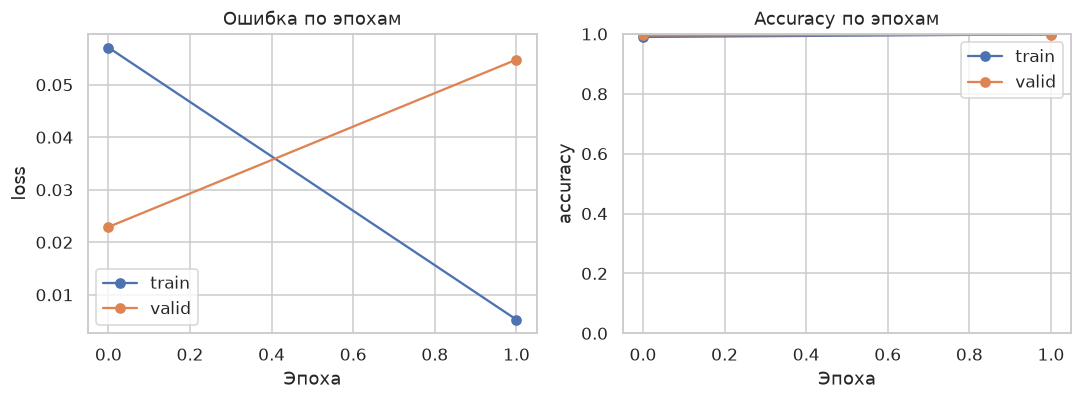

In [9]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

tf.keras.utils.set_random_seed(42)

fit_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)
encoder = LabelEncoder()
encoder.fit(LABELS)
n_classes = len(encoder.classes_)
print("классы сети:", list(encoder.classes_))

y_fit = encoder.transform(fit_df["tag"].to_numpy())
y_val = encoder.transform(val_df["tag"].to_numpy())
y_test = encoder.transform(test_df["tag"].to_numpy())

batch_size = 64
train_data = tf.data.Dataset.from_tensor_slices((fit_df["word"].to_numpy(), y_fit))
train_data = train_data.shuffle(10000, seed=42).batch(batch_size)
val_data = tf.data.Dataset.from_tensor_slices((val_df["word"].to_numpy(), y_val)).batch(batch_size)
train_data = train_data.prefetch(tf.data.AUTOTUNE)
val_data = val_data.prefetch(tf.data.AUTOTUNE)

def custom_standardization(input_data):
    return input_data

vocab_size = 30000
seq_len = 10
vectorize_layer = tf.keras.layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=seq_len,
)
vectorize_layer.adapt(train_data.map(lambda x, y: x))
print("слов в словаре сети:", len(vectorize_layer.get_vocabulary()))

embedding_dim = 64

class modelNER(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.emb = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gPool = tf.keras.layers.GlobalMaxPooling1D()
        self.fc1 = tf.keras.layers.Dense(300, activation="relu")
        self.fc2 = tf.keras.layers.Dense(50, activation="relu")
        self.fc3 = tf.keras.layers.Dense(n_classes, activation="softmax")

    def call(self, x):
        x = vectorize_layer(x)
        x = self.emb(x)
        pool_x = self.gPool(x)
        fc_x = self.fc1(pool_x)
        fc_x = self.fc2(fc_x)
        concat_x = tf.concat([pool_x, fc_x], axis=1)
        return self.fc3(concat_x)

ner_model = modelNER()
ner_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=1, restore_best_weights=True
)
history = ner_model.fit(train_data, validation_data=val_data, epochs=3, callbacks=[early], verbose=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(history.history["loss"], marker="o", label="train")
axes[0].plot(history.history["val_loss"], marker="o", label="valid")
axes[0].set_title("Ошибка по эпохам")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[1].plot(history.history["accuracy"], marker="o", label="train")
axes[1].plot(history.history["val_accuracy"], marker="o", label="valid")
axes[1].set_title("Accuracy по эпохам")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()




,модель,accuracy,macro-F1 всех классов,macro-F1 сущностей
0,Константа O,0.977,0.165,0.000
1,Сеть,0.995,0.608,0.442


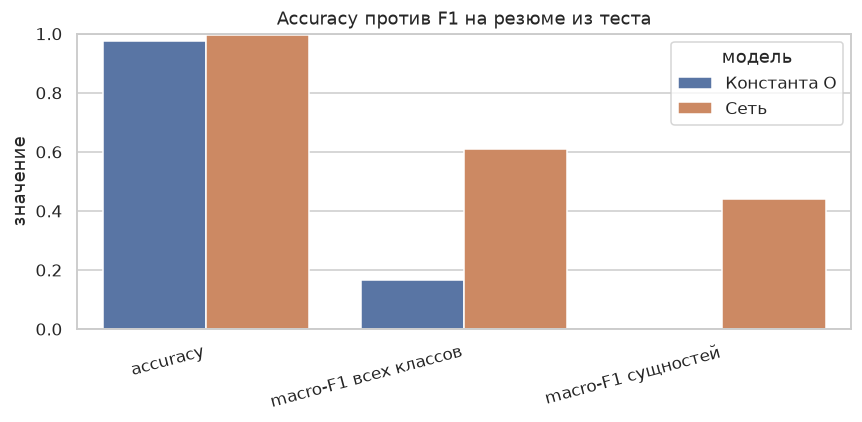

              precision    recall  f1-score   support

    POSITION      0.932     0.750     0.831       400
         ORG      0.881     0.923     0.902       442
       SKILL      1.000     0.849     0.918       252
         EDU      0.000     0.000     0.000        21
      PERIOD      0.000     0.000     0.000        39
         LOC      0.000     0.000     0.000         0
           O      0.997     1.000     0.998     48843

    accuracy                          0.995     49997
   macro avg      0.544     0.503     0.521     49997
weighted avg      0.994     0.995     0.995     49997



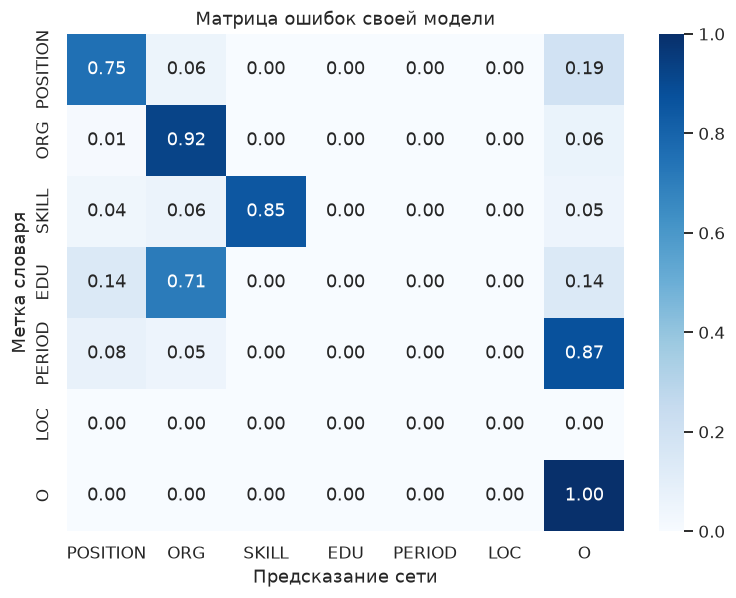

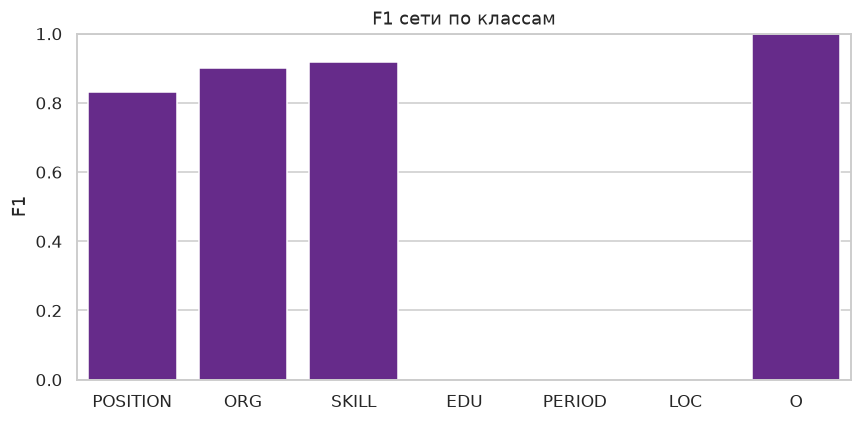

сущности, которые сеть не повторила (до 15): 232


,word,tag,pred
0,директором,POSITION,O
1,powerpoint,SKILL,O
2,педагогам,POSITION,O
3,преподавателям,POSITION,O
4,преподавателям,POSITION,O
5,Врач,POSITION,O
6,ординатор,POSITION,O
7,2017,PERIOD,O
8,Врач,POSITION,O
9,ординатор,POSITION,O


Тестовые предложения. Цвет — предсказание сети, красная обводка — расхождение со словарём


In [10]:
test_ds = tf.data.Dataset.from_tensor_slices(test_df["word"].to_numpy()).batch(256)
probs = ner_model.predict(test_ds, verbose=0)
pred_tags = encoder.inverse_transform(probs.argmax(axis=1))
gold_tags = test_df["tag"].to_numpy()
const_tags = np.array(["O"] * len(gold_tags))
entity_labels = [label for label in LABELS if label != "O"]

def metric_row(name, pred):
    return {
        "модель": name,
        "accuracy": accuracy_score(gold_tags, pred),
        "macro-F1 всех классов": f1_score(gold_tags, pred, average="macro", zero_division=0),
        "macro-F1 сущностей": f1_score(
            gold_tags, pred, labels=entity_labels, average="macro", zero_division=0
        ),
    }

summary = pd.DataFrame([
    metric_row("Константа O", const_tags),
    metric_row("Сеть", pred_tags),
])
display(summary.round(3))

long = summary.melt(id_vars="модель", var_name="метрика", value_name="значение")
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=long, x="метрика", y="значение", hue="модель", ax=ax)
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_title("Accuracy против F1 на резюме из теста")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

print(classification_report(gold_tags, pred_tags, labels=LABELS, zero_division=0, digits=3))

fig, ax = plt.subplots(figsize=(7.2, 5.6))
matrix = confusion_matrix(gold_tags, pred_tags, labels=LABELS, normalize="true")
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Предсказание сети")
ax.set_ylabel("Метка словаря")
ax.set_title("Матрица ошибок своей модели")
plt.tight_layout()
plt.show()

per_class = f1_score(gold_tags, pred_tags, labels=LABELS, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=LABELS, y=per_class, ax=ax, color="#6a1b9a")
ax.set_ylim(0, 1)
ax.set_ylabel("F1")
ax.set_title("F1 сети по классам")
plt.tight_layout()
plt.show()

scored = test_df.copy()
scored["pred"] = pred_tags
misses = scored[scored["tag"].ne(scored["pred"]) & scored["tag"].ne("O")]
print("сущности, которые сеть не повторила (до 15):", len(misses))
display(misses.loc[:, ["word", "tag", "pred"]].head(15).reset_index(drop=True))

def render_pred(words, gold, pred):
    chunks = []
    for word, gold_tag, pred_tag in zip(words, gold, pred):
        safe = html.escape(str(word))
        if gold_tag == "O" and pred_tag == "O":
            chunks.append(safe)
            continue
        shown = pred_tag if pred_tag != "O" else gold_tag
        outline = "" if gold_tag == pred_tag else "outline:2px solid #c62828;"
        color = COLORS.get(shown, "#eeeeee")
        chunks.append(
            f'<span title="словарь={gold_tag}, модель={pred_tag}" '
            f'style="background:{color};{outline}padding:1px 4px;border-radius:3px">'
            f'{safe}<sub>{html.escape(str(pred_tag))}</sub></span>'
        )
    display(HTML("<p>" + " ".join(chunks) + "</p>"))

print("Тестовые предложения. Цвет — предсказание сети, красная обводка — расхождение со словарём")
shown = 0
for (_, _), group in scored.groupby(["doc", "sent"], sort=False):
    words = group["word"].tolist()
    gold = group["tag"].tolist()
    pred = group["pred"].tolist()
    if any(tag != "O" for tag in gold) and 5 <= len(words) <= 22:
        render_pred(words, gold, pred)
        shown += 1
    if shown >= 6:
        break





## 6. Память + LogReg

Это логистическая регрессия по кускам слова.

Слово режется на фрагменты по 2–4 символа. Если такое написание уже было в обучении, регрессию не спрашиваем: ставим самую частую метку этого слова. Если написания не было, метку ставит регрессия с балансом классов. Поэтому «прорабами» оказывается рядом с уже виденным «прораб».

В таблице та же регрессия есть и отдельно: только по символам и только с балансом классов. Рабочий вариант — память с откатом на сбалансированную регрессию. Сеть для сравнения та же, что в предыдущем разделе.


,модель,accuracy,macro-F1 всех классов,macro-F1 сущностей
0,Память + LogReg,0.997,0.905,0.739
1,Память слова,0.998,0.880,0.713
2,"LogReg, баланс классов",0.991,0.802,0.636
3,LogReg по символам,0.996,0.787,0.621
4,Сеть,0.995,0.608,0.442
5,Константа O,0.977,0.165,0.000


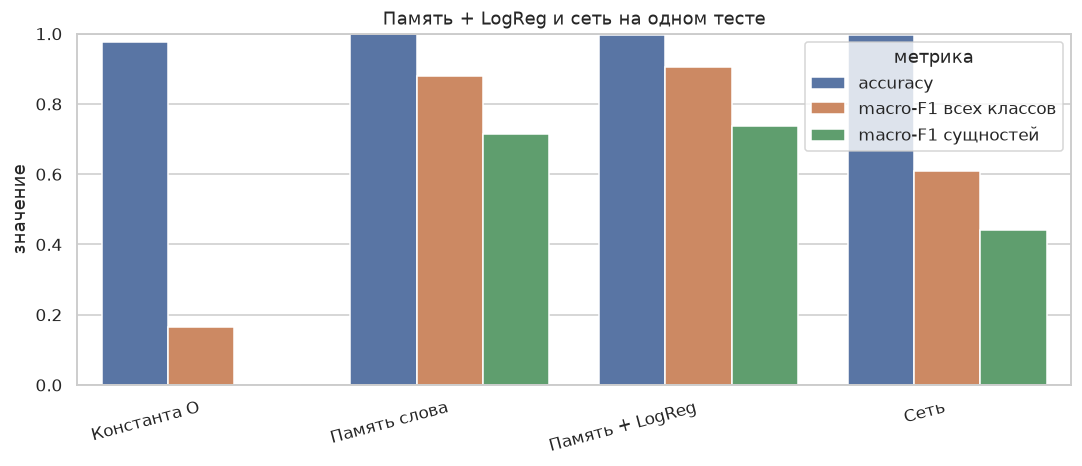

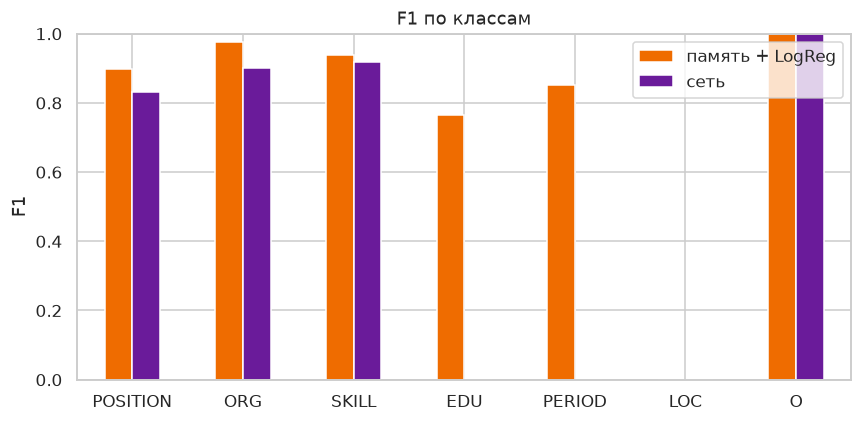

незнакомых слов в тесте: 3873 (7.7%)


,модель,accuracy на незнакомых,macro-F1 сущностей на незнакомых
0,Память слова,0.975,0.000
1,Память + LogReg,0.957,0.314
2,Сеть,0.975,0.000


Незнакомые сущности: кто какую метку поставил


,word,словарь,память + LogReg,сеть
0,преподавателям,POSITION,POSITION,O
1,преподавателям,POSITION,POSITION,O
2,ординатор,POSITION,POSITION,O
3,ординатор,POSITION,POSITION,O
4,прорабами,POSITION,POSITION,O
5,прорабами,POSITION,POSITION,O
6,заводу,ORG,ORG,O
7,лаборантом,POSITION,POSITION,O
8,гостиницах,ORG,ORG,O
9,клиникой,ORG,ORG,O


In [11]:
from collections import Counter
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import LogisticRegression

# Память + LogReg.
# Знакомое написание берём из памяти: самая частая метка этого слова в обучении.
# Незнакомое режем на куски по 2–4 символа и отдаём логистической регрессии
# с балансом классов, поэтому «прорабами» оказывается рядом с уже виденной «прораб».
train_vocab = set(train_df["key"])
vectorizer = HashingVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 4),
    n_features=2**12,
    alternate_sign=False,
)
x_train_vec = vectorizer.fit_transform(train_df["word"].tolist())
x_test_vec = vectorizer.transform(test_df["word"].tolist())

word_memory = {}
for key, tag in zip(train_df["key"], train_df["tag"]):
    word_memory.setdefault(key, Counter())[tag] += 1
word_memory = {key: counts.most_common(1)[0][0] for key, counts in word_memory.items()}

logreg = LogisticRegression(max_iter=400, random_state=42)
logreg.fit(x_train_vec, train_df["tag"])
logreg_balanced = LogisticRegression(max_iter=400, class_weight="balanced", random_state=42)
logreg_balanced.fit(x_train_vec, train_df["tag"])

pred_memory = [word_memory.get(key, "O") for key in test_df["key"]]
pred_logreg = logreg.predict(x_test_vec)
pred_balanced = logreg_balanced.predict(x_test_vec)
pred_old = [
    remembered if key in train_vocab else guessed
    for key, remembered, guessed in zip(test_df["key"], pred_memory, pred_balanced)
]

compare = pd.DataFrame([
    metric_row("Константа O", const_tags),
    metric_row("Память слова", pred_memory),
    metric_row("LogReg по символам", pred_logreg),
    metric_row("LogReg, баланс классов", pred_balanced),
    metric_row("Память + LogReg", pred_old),
    metric_row("Сеть", pred_tags),
]).sort_values("macro-F1 сущностей", ascending=False).reset_index(drop=True)
display(compare.round(3))

plot_models = [
    "Константа O",
    "Память слова",
    "Память + LogReg",
    "Сеть",
]
plot_df = compare[compare["модель"].isin(plot_models)]
long = plot_df.melt(id_vars="модель", var_name="метрика", value_name="значение")
fig, ax = plt.subplots(figsize=(10, 4.4))
sns.barplot(data=long, x="модель", y="значение", hue="метрика", ax=ax,
            order=plot_models)
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_title("Память + LogReg и сеть на одном тесте")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

f1_old = f1_score(gold_tags, pred_old, labels=LABELS, average=None, zero_division=0)
f1_ner = f1_score(gold_tags, pred_tags, labels=LABELS, average=None, zero_division=0)
per_class = pd.DataFrame({"класс": LABELS, "память + LogReg": f1_old, "сеть": f1_ner})
fig, ax = plt.subplots(figsize=(8, 4))
per_class.plot(x="класс", y=["память + LogReg", "сеть"], kind="bar", ax=ax, color=["#ef6c00", "#6a1b9a"])
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("F1")
ax.set_title("F1 по классам")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

oov = ~test_df["key"].isin(train_vocab).to_numpy()
oov_gold = gold_tags[oov]
print(f"незнакомых слов в тесте: {int(oov.sum())} ({oov.mean():.1%})")
oov_rows = []
for name, pred in [
    ("Память слова", pred_memory),
    ("Память + LogReg", pred_old),
    ("Сеть", pred_tags),
]:
    pred_oov = np.asarray(pred)[oov]
    oov_rows.append({
        "модель": name,
        "accuracy на незнакомых": accuracy_score(oov_gold, pred_oov),
        "macro-F1 сущностей на незнакомых": f1_score(
            oov_gold, pred_oov, labels=entity_labels, average="macro", zero_division=0
        ),
    })
display(pd.DataFrame(oov_rows).round(3))

side = test_df.copy()
side["память + LogReg"] = pred_old
side["сеть"] = pred_tags
entity_oov = side[oov & side["tag"].ne("O")]
print("Незнакомые сущности: кто какую метку поставил")
display(
    entity_oov.loc[:, ["word", "tag", "память + LogReg", "сеть"]]
    .head(12)
    .rename(columns={"tag": "словарь"})
    .reset_index(drop=True)
)




**Сравнение.** Память + LogReg на всём тесте сильнее сети: macro-F1 сущностей 0,739 при accuracy 0,997. У сети accuracy 0,995, а macro-F1 сущностей 0,442. Константа «все слова — фон» даёт accuracy 0,977 и F1 сущностей 0. По accuracy три варианта почти рядом, по сущностям — нет.

Сеть смотрит на слово целиком. Новая форма («прорабами» при знакомом «прораб») для неё неизвестный индекс и чаще уходит в фон. Регистр она тоже не приводит к одному виду: «Врач» в начале фразы — другое слово, чем «врач». Память + LogReg регистр схлопывает и незнакомую форму собирает из кусков.

Незнакомых слов в тесте 3873, это 7,7%. Одна только память слова и сеть ставят им фон, F1 сущностей на них равен 0. Память + LogReg на этих словах получает 0,314: «преподавателям», «ординатор», «прорабами», «заводу», «лаборантом» она относит к должности или месту работы.


**Вывод по сети.** На тесте accuracy сети 0,995 против 0,977 у константы «все слова — фон». Фон — это 48843 слова из 49997, поэтому accuracy завышена у любой модели, которая почти не ошибается на обычных словах. Macro-F1 сущностей у константы равен 0, у сети 0,442. По классам: должности 0,831, места работы 0,902, программы 0,918.

Эпоху берём по ошибке на словах, отложенных из обучения, а не по тесту. После первой эпохи эта ошибка 0,023, accuracy на них 0,995. После второй ошибка выросла до 0,055, хотя accuracy стала 0,998: почти все слова по-прежнему получают верный класс, но сеть сильнее уверена в обучающих строках, и редкие промахи дороже обходятся. На графике ошибка на отложенных словах растёт. В предсказаниях остаются веса первой эпохи.

Промахи сети — другое написание тех же слов: «директором», «преподавателям», «прорабами», «Врач», «2017», «powerpoint». Образование и годы в тесте не находятся: их 21 и 39 слов, за одну устойчивую эпоху этого мало. Городов в тесте нет, все 4 попали в обучение, поэтому по ним качество не измерить. Красная обводка на примерах — слово, где предсказание не совпало с нашим словарём.


## 7. Итог

1. Части речи ставит готовый анализатор `pymorphy3`. Он отделяет существительное «бухгалтер» от прилагательного «бухгалтерской» и даёт лемму. Правила по окончаниям для этого не используем.
2. `UnigramTagger` покрывает знакомые слова и на них совпадает с анализатором. `BigramTagger` и `TrigramTagger` без отката оставляют без части речи большинство слов: нужного контекста в обучении не было. С откатом пустыми остаются 2700 токенов, которых не было в обучении. Они подсвечены жёлтым.
3. Сущности заданы вручную под резюме: должность, место работы, программа, образование, год, город. Остальные слова — фон, их 97,8%. Это ожидаемо: сущность здесь редкое слово, а не каждое.
4. Сеть учится ставить слову одну из семи меток. Accuracy 0,995, macro-F1 сущностей 0,442. Память + LogReg знакомому написанию ставит метку из обучения, новому слову отдаёт логистическую регрессию по кускам из 2–4 символов: accuracy 0,997, macro-F1 сущностей 0,739. На незнакомых словах у сети F1 сущностей 0, у памяти + LogReg 0,314.
5. Метки, с которыми сравниваем модели, повторяют наш список. Слова вне списка и проверка, и модели считают фоном. Части речи — первый, самый частый разбор анализатора, без учёта соседних слов.
